# Ashwood-Style Full-Session Biased Block Extension

This notebook extends the Ashwood-style mouse-level GLM-HMM analysis from the first-90 unbiased baseline trials to full sessions with 50/50, 80/20, and 20/80 blocks.


In [1]:
import sys
import platform
import importlib.metadata as md

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("Platform:", platform.platform())

packages = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "jupyter",
]

for pkg in packages:
    try:
        print(pkg, md.version(pkg))
    except md.PackageNotFoundError:
        print(pkg, "not installed")

Python: 3.11.5 (main, Sep 11 2023, 08:17:37) [Clang 14.0.6 ]
Python executable: /usr/local/anaconda3/bin/python
Platform: macOS-26.3.1-arm64-arm-64bit
numpy 1.24.4
pandas 2.3.3
scipy 1.15.3
scikit-learn 1.3.0
matplotlib 3.7.2
seaborn 0.12.2
jupyter 1.0.0


#### **1.1 import python libraries.**

In [2]:
# Import the libraries and the local ssm_new_full package used to fit the Ashwood-style GLM-HMM.

import os
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd


/usr/local/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


#### **1.2 import local ssm_new_full package**

In [3]:
# Find the project folder by walking upward until the local ssm_new_full package is found.
current_path = Path.cwd().resolve()
project_path = next(
    (candidate for candidate in [current_path, *current_path.parents] if (candidate / 'ssm_new_full').exists()),
    None,
)
if project_path is None:
    raise FileNotFoundError(
        'Could not find the local ssm_new_full package. Run this notebook from the project folder or one of its subfolders.'
    )
if str(project_path) not in sys.path:
    sys.path.insert(0, str(project_path))

import ssm_new_full as ssm

print('Project path:', project_path)
print('ssm_new_full version:', getattr(ssm, '__version__', 'version not found'))


Project path: /Users/tolganaymuntinova/Documents/ibl-project
ssm_new_full version: 0.1.0-glmhmm-python311


#### **1.3 Load Completed Q3 workspace**

This loads the base `IBL_behavior_dataQ3.ipynb` workspace and uses `df_q3_model` as the source table. 

The GLM-HMM engine is imported directly from `ssm_new_full`, original link Read more here https://github.com/zashwood/ssm.git 


In [4]:
# Load the base Q3 workspace and use df_q3_model as the only source table for this analysis.

workspace_path = Path('notebook_outputs/q3_workspace.pkl')
if not workspace_path.exists():
    workspace_path = project_path / 'notebook_outputs/q3_workspace.pkl'

if 'df_q3_model' not in globals():
    with open(workspace_path, 'rb') as f:
        globals().update(pickle.load(f))

required_names = ['df_q3_model']

missing = [name for name in required_names if name not in globals()]

if missing:
    raise NameError(f'Missing required variables from q3_workspace.pkl: {missing}')

display(all_trials.columns)

Index(['session', 'intervals_0', 'intervals_1', 'goCue_times',
       'response_times', 'choice', 'stimOn_times', 'contrastLeft',
       'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume',
       'probabilityLeft', 'firstMovement_times', 'goCueTrigger_times',
       'stimOnTrigger_times', 'stimOffTrigger_times',
       'stimFreezeTrigger_times', 'stimOff_times', 'stimFreeze_times', 'phase',
       'position', 'quiescence', 'protocol_number', 'session_start_time',
       'training_status', 'lab', 'subject', 'number', 'task_protocol',
       'projects', 'performance_easy', 'training_day', 'session_number',
       'signed_contrast', 'trial_index', 'sex', 'sex_raw'],
      dtype='object')

#### **1.4 Settings**


In [5]:
# Set the analysis options for mouse/session filtering, cross-validation, GLM-HMM fitting, and output files.

# CHANGE ONLY THESE TWO LINES.
# TASK_TRIAL_WINDOW options:
# - 'first90_session' = first 90 trials of the whole session
# - 'first90_block'   = first 90 trials after each selected block starts
# - 'full_session'    = all trials from selected block(s)
TASK_TRIAL_WINDOW = 'first90_session'

# TASK_BLOCK_SET options:
# - '50_50'      = 50/50 unbiased block only
# - '80_20'      = 80/20 left-biased block only
# - '20_80'      = 20/80 right-biased block only
# - 'all_blocks' = 50/50 + 80/20 + 20/80 together
TASK_BLOCK_SET = '50_50'

# Block definitions from the IBL task variable probabilityLeft.

TASK_BLOCK_TYPE_TO_PROBABILITY_LEFT = {
    'unbiased_50_50': 0.5,
    'left_biased_80_20': 0.8,
    'right_biased_20_80': 0.2,
}
TASK_PROBABILITY_TO_BLOCK_TYPE = {
    probability: block_type
    for block_type, probability in TASK_BLOCK_TYPE_TO_PROBABILITY_LEFT.items()
}
TASK_BLOCK_LABELS = {
    'unbiased_50_50': '50/50 unbiased',
    'left_biased_80_20': '80/20 left-biased',
    'right_biased_20_80': '20/80 right-biased',
}
TASK_ALL_BLOCK_TYPES = [
    'unbiased_50_50',
    'left_biased_80_20',
    'right_biased_20_80',
]

# Convert the two simple choices above into the variables used by the analysis code.
TASK_TRIAL_WINDOW_OPTIONS = {
    'first90_session': {
        'trial_scope': 'first_n_session_trials',
        'first_n_trials': 90,
    },
    'first90_block': {
        'trial_scope': 'first_n_block_trials',
        'first_n_trials': 90,
    },
    'full_session': {
        'trial_scope': 'full_session',
        'first_n_trials': None,
    },
}
TASK_BLOCK_SET_OPTIONS = {
    '50_50': ['unbiased_50_50'],
    '80_20': ['left_biased_80_20'],
    '20_80': ['right_biased_20_80'],
    'all_blocks': TASK_ALL_BLOCK_TYPES,
}

if TASK_TRIAL_WINDOW not in TASK_TRIAL_WINDOW_OPTIONS:
    raise ValueError(f'Unknown TASK_TRIAL_WINDOW: {TASK_TRIAL_WINDOW}')
if TASK_BLOCK_SET not in TASK_BLOCK_SET_OPTIONS:
    raise ValueError(f'Unknown TASK_BLOCK_SET: {TASK_BLOCK_SET}')

TASK_SELECTED_WINDOW = TASK_TRIAL_WINDOW_OPTIONS[TASK_TRIAL_WINDOW]
TASK_TRIAL_SCOPE = TASK_SELECTED_WINDOW['trial_scope']
TASK_FIRST_N_TRIALS = TASK_SELECTED_WINDOW['first_n_trials']
TASK_SELECTED_BLOCK_TYPES = TASK_BLOCK_SET_OPTIONS[TASK_BLOCK_SET]
TASK_SELECTED_PROBABILITY_LEFT_VALUES = [
    TASK_BLOCK_TYPE_TO_PROBABILITY_LEFT[block_type]
    for block_type in TASK_SELECTED_BLOCK_TYPES
]
TASK_ALL_BLOCK_PROBABILITIES = list(TASK_PROBABILITY_TO_BLOCK_TYPE.keys())
TASK_IS_ASHWOOD_FIRST90_BASELINE = (
    TASK_TRIAL_WINDOW == 'first90_session'
    and TASK_BLOCK_SET == '50_50'
)
TASK_ANALYSIS_PRESET = f'{TASK_TRIAL_WINDOW}__{TASK_BLOCK_SET}'
TASK_ANALYSIS_NAME = (
    f"{TASK_TRIAL_SCOPE}__" + '__'.join(TASK_SELECTED_BLOCK_TYPES)
)

# Mouse/session filtering settings.
TASK_MAX_MICE = None
TASK_STRICT_MIN_SESSIONS_PER_MOUSE = 30
TASK_ALLOW_AVAILABLE_DATA_FALLBACK = True
TASK_RELAXED_MIN_SESSIONS_PER_MOUSE = 3
TASK_MIN_TRIALS_PER_MOUSE = 200
TASK_MIN_SESSION_TRIALS = 80
TASK_MAX_VIOLATIONS_50 = 9
TASK_MAX_VIOLATION_FRACTION = 0.10

# Cross-validation and GLM-HMM fitting settings.
TASK_NUM_FOLDS = 2
TASK_MODEL_K_LIST = [1, 3]
TASK_RUN_K4_OPTIONAL = False
if TASK_RUN_K4_OPTIONAL and 4 not in TASK_MODEL_K_LIST:
    TASK_MODEL_K_LIST.append(4)

TASK_HMM_MAX_ITER = 10
TASK_HMM_N_RESTARTS = 1
TASK_STAY_PROBABILITY = 0.95
TASK_PRIOR_SIGMA = 100

# Numeric and interpretation settings.
TASK_BALANCE_TOLERANCE = 0.10
TASK_PROBABILITY_LEFT_TOLERANCE = 1e-6
TASK_NORMALIZE_STIMULUS = True
TASK_ENGAGED_CONTRAST_MIN = 0.0
TASK_BIAS_SIGN_MIN = 0.0

OUTPUT_DIR = Path('notebook_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Trial window:', TASK_TRIAL_WINDOW)
print('Block set:', TASK_BLOCK_SET)
print('Analysis preset:', TASK_ANALYSIS_PRESET)
print('Trial scope:', TASK_TRIAL_SCOPE)
print('First N trials:', TASK_FIRST_N_TRIALS)
print('Selected blocks:', TASK_SELECTED_BLOCK_TYPES)
print('Selected probabilityLeft values:', TASK_SELECTED_PROBABILITY_LEFT_VALUES)


Trial window: first90_session
Block set: 50_50
Analysis preset: first90_session__50_50
Trial scope: first_n_session_trials
First N trials: 90
Selected blocks: ['unbiased_50_50']
Selected probabilityLeft values: [0.5]


### **2. Build Analysis Dataset from df_q3_model**

This extension notebook works like a simple constructor.

In the Settings cell, change only two lines:

```python
TASK_TRIAL_WINDOW = 'full_session'
TASK_BLOCK_SET = 'all_blocks'
```

Choose the trial window:

```text
first90_session -> first 90 trials of the whole session
first90_block   -> first 90 trials after each selected block starts
full_session    -> all trials from selected block(s)
```

Choose the block set:

```text
50_50      -> 50/50 only
80_20      -> 80/20 only
20_80      -> 20/80 only
all_blocks -> 50/50 + 80/20 + 20/80 together
```

Examples:

```python
TASK_TRIAL_WINDOW = 'first90_block'
TASK_BLOCK_SET = '80_20'
```

```python
TASK_TRIAL_WINDOW = 'full_session'
TASK_BLOCK_SET = '20_80'
```

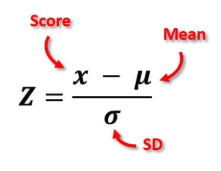

#### **2.1 Prepare Ashwood Baseline Data**

We create `ashwood_analysis_df` from `df_q3_model`, 

- sort trials in the correct order by `intervals_0`, 

- create `trial numbers` column within each session, 

- create the `bias` column, and 

- build the Ashwood history predictors: `prev_choice_centered`, `prev_reward_centered`, and `prev_choice_x_reward`

This gives us a clean dataframe with only the columns needed for the Ashwood-style GLM-HMM baseline analysis.


In [6]:
# Build the analysis dataframe from df_q3_model.
# This keeps the Ashwood-style regressors and adds block labels for the extension analysis.

model_sort_columns = ['subject', 'session', 'intervals_0']
model_time_sort_column = 'intervals_0'

ashwood_analysis_df = df_q3_model.sort_values(model_sort_columns).copy(deep=True)
display(ashwood_analysis_df.head(5))

ashwood_analysis_df['ashwood_trial_number'] = (
    ashwood_analysis_df.groupby(['subject', 'session']).cumcount() + 1
)

ashwood_analysis_df['bias'] = 1.0

ashwood_analysis_df['prev_choice_centered'] = (
    ashwood_analysis_df['prev_choice_binary'].astype(float) * 2 - 1
)
ashwood_analysis_df['prev_reward_centered'] = (
    ashwood_analysis_df['prev_rewarded'].astype(float) * 2 - 1
)
ashwood_analysis_df['prev_choice_x_reward'] = (
    ashwood_analysis_df['prev_choice_centered'] * ashwood_analysis_df['prev_reward_centered']
)

# Label the task block from probabilityLeft.
probability_values = ashwood_analysis_df['probabilityLeft'].astype(float)
block_conditions = [
    np.isclose(probability_values, probability, atol=TASK_PROBABILITY_LEFT_TOLERANCE)
    for probability in TASK_ALL_BLOCK_PROBABILITIES
]
block_labels = [TASK_PROBABILITY_TO_BLOCK_TYPE[probability] for probability in TASK_ALL_BLOCK_PROBABILITIES]
ashwood_analysis_df['block_type'] = np.select(block_conditions, block_labels, default='other')

# Mark trials where probabilityLeft changes within a session.
previous_probability_left = ashwood_analysis_df.groupby(['subject', 'session'])['probabilityLeft'].shift(1)

ashwood_analysis_df['block_switch_trial'] = (
    previous_probability_left.notna()
    & ((ashwood_analysis_df['probabilityLeft'] - previous_probability_left).abs() > TASK_PROBABILITY_LEFT_TOLERANCE)
)

ashwood_analysis_df['block_segment_index'] = (
    ashwood_analysis_df.groupby(['subject', 'session'])['block_switch_trial']
    .cumsum()
    .astype(int)
)
ashwood_analysis_df['trials_after_block_switch'] = (
    ashwood_analysis_df.groupby(['subject', 'session', 'block_segment_index']).cumcount()
)

needed_cols = [
    'subject',
    'session',
    'intervals_0',
    'ashwood_trial_number',
    'probabilityLeft',
    'block_type',
    'block_switch_trial',
    'block_segment_index',
    'trials_after_block_switch',
    'choice',
    'choice_binary',
    'signed_contrast',
    'bias',
    'prev_choice_binary',
    'prev_rewarded',
    'prev_choice_centered',
    'prev_reward_centered',
    'prev_choice_x_reward',
]

ashwood_analysis_df = ashwood_analysis_df[needed_cols].copy(deep=True)

display(ashwood_analysis_df.head(1))


,session,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,...,session_number,signed_contrast,trial_index,sex,sex_raw,choice_binary,prev_choice_binary,prev_feedbackType,prev_rewarded,behavior_type
692,034e726f-b35f-41e0-8d6c-a22cc32391fb,27.458533,32.351466,28.786100,29.768148,1.0,28.785167,NaN,0.125,29.769100,...,NaN,-0.125,1,male,M,1,1,1.0,1,win-stay
693,034e726f-b35f-41e0-8d6c-a22cc32391fb,32.737167,35.201698,33.269400,33.616677,1.0,33.268500,0.25,NaN,33.616800,...,NaN,0.250,2,male,M,1,1,-1.0,0,lose-stay
694,034e726f-b35f-41e0-8d6c-a22cc32391fb,35.557900,39.018432,37.102400,37.434516,-1.0,37.101567,NaN,1.000,37.434633,...,NaN,-1.000,3,male,M,0,1,1.0,1,win-shift
695,034e726f-b35f-41e0-8d6c-a22cc32391fb,39.389333,41.951564,39.936033,40.377645,1.0,39.934933,0.00,NaN,40.377733,...,NaN,0.000,4,male,M,1,0,1.0,1,win-shift
696,034e726f-b35f-41e0-8d6c-a22cc32391fb,42.328267,45.751499,42.852700,43.175274,1.0,42.851600,NaN,0.000,43.176033,...,NaN,-0.000,5,male,M,1,1,1.0,1,win-stay


,subject,session,intervals_0,ashwood_trial_number,probabilityLeft,block_type,block_switch_trial,block_segment_index,trials_after_block_switch,choice,choice_binary,signed_contrast,bias,prev_choice_binary,prev_rewarded,prev_choice_centered,prev_reward_centered,prev_choice_x_reward
692,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,27.458533,1,0.5,unbiased_50_50,False,0,0,1.0,1,-0.125,1.0,1,1,1.0,1.0,1.0


#### **2.2 Filter Trials And Sessions**

The filter is controlled by two settings:

```python
TASK_TRIAL_WINDOW

TASK_BLOCK_SET
```

This makes it clear whether you are analyzing first-90 trials, full sessions, 50/50, 80/20, 20/80, or all blocks together.


#### **2.3 Apply Trial-Level Filter**

This step selects the trials used for fitting and decoding.

It first applies `TASK_TRIAL_WINDOW`, then applies `TASK_BLOCK_SET`.


In [7]:
# Select trials using the preset constructor.
# First choose the time window, then choose the block types.

if TASK_TRIAL_SCOPE == 'first_n_session_trials':
    trial_window_mask = ashwood_analysis_df['ashwood_trial_number'] <= TASK_FIRST_N_TRIALS

elif TASK_TRIAL_SCOPE == 'first_n_block_trials':
    trial_window_mask = ashwood_analysis_df['trials_after_block_switch'] < TASK_FIRST_N_TRIALS

elif TASK_TRIAL_SCOPE == 'full_session':
    trial_window_mask = pd.Series(True, index=ashwood_analysis_df.index)

else:
    raise ValueError(f'Unknown TASK_TRIAL_SCOPE: {TASK_TRIAL_SCOPE}')

block_selection_mask = pd.Series(False, index=ashwood_analysis_df.index)

for probability_left in TASK_SELECTED_PROBABILITY_LEFT_VALUES:
    block_selection_mask = block_selection_mask | ((ashwood_analysis_df['probabilityLeft'] - probability_left).abs() <= TASK_PROBABILITY_LEFT_TOLERANCE )

trial_selection_mask = trial_window_mask & block_selection_mask

baseline_source = (
    f'preset={TASK_ANALYSIS_PRESET}; '
    f'trial_scope={TASK_TRIAL_SCOPE}; '
    f'first_n_trials={TASK_FIRST_N_TRIALS}; '
    f'blocks={TASK_SELECTED_BLOCK_TYPES}'
)

baseline_candidate_df = ashwood_analysis_df[trial_selection_mask].copy()

# Mark violation-like trials.
# In IBL raw choice, choice == 0 means no valid left/right response.
baseline_candidate_df['ashwood_violation_like'] = baseline_candidate_df['choice'].eq(0)

# Keep only valid binary-choice trials. GLM-HMM needs choices coded as 0 or 1.
baseline_df = baseline_candidate_df[
    baseline_candidate_df['choice_binary'].isin([0, 1])
].copy()

baseline_df['choice_binary'] = baseline_df['choice_binary'].astype(int)

# Remove trials with missing model inputs or block labels.
baseline_df = baseline_df.dropna(
    subset=[
        'subject',
        'session',
        'choice_binary',
        'intervals_0',
        'probabilityLeft',
        'block_type',
        'prev_choice_centered',
        'prev_choice_x_reward',
        'bias',
        'signed_contrast',
    ]
).copy()

display(baseline_df.head(1))


,subject,session,intervals_0,ashwood_trial_number,probabilityLeft,block_type,block_switch_trial,block_segment_index,trials_after_block_switch,choice,choice_binary,signed_contrast,bias,prev_choice_binary,prev_rewarded,prev_choice_centered,prev_reward_centered,prev_choice_x_reward,ashwood_violation_like
692,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,27.458533,1,0.5,unbiased_50_50,False,0,0,1.0,1,-0.125,1.0,1,1,1.0,1.0,1.0,False


#### **2.4 Apply Session-Level Filter**

This step keeps sessions with enough usable trials and acceptable violation rate.

For `baseline_50_50`, sessions must also be confirmed 50/50 baseline sessions.

For `full_session_blocks`, sessions only need to contain requested block trials from `probabilityLeft` values 0.5, 0.8, or 0.2.


In [8]:
# Check each session and keep sessions that are usable for the selected analysis mode.

baseline_session_check_df = (
    baseline_candidate_df
    .groupby(['subject', 'session'], as_index=False)
    .agg(
        n_candidate_trials=('choice_binary', 'size'),
        n_violations_50=('ashwood_violation_like', 'sum'),
        mean_probability_left=('probabilityLeft', 'mean'),
        block_types=('block_type', lambda x: ', '.join(sorted(pd.unique(x.dropna())))),
        n_block_switch_trials=('block_switch_trial', 'sum'),
    )
)

valid_session_counts_df = (
    baseline_df
    .groupby(['subject', 'session'], as_index=False)
    .agg(
        n_trials=('choice_binary', 'size'),
        n_right_stimulus=('signed_contrast', lambda x: (x > 0).sum()),
        n_left_stimulus=('signed_contrast', lambda x: (x < 0).sum()),
        n_unbiased_50_50=('block_type', lambda x: (x == 'unbiased_50_50').sum()),
        n_left_biased_80_20=('block_type', lambda x: (x == 'left_biased_80_20').sum()),
        n_right_biased_20_80=('block_type', lambda x: (x == 'right_biased_20_80').sum()),
    )
)

baseline_session_check_df = (
    baseline_session_check_df
    .merge(valid_session_counts_df, on=['subject', 'session'], how='left')
    .fillna({
        'n_trials': 0,
        'n_right_stimulus': 0,
        'n_left_stimulus': 0,
        'n_unbiased_50_50': 0,
        'n_left_biased_80_20': 0,
        'n_right_biased_20_80': 0,
    })
)

count_columns = [
    'n_trials',
    'n_right_stimulus',
    'n_left_stimulus',
    'n_unbiased_50_50',
    'n_left_biased_80_20',
    'n_right_biased_20_80',
]
baseline_session_check_df[count_columns] = baseline_session_check_df[count_columns].astype(int)

baseline_session_check_df['n_nonzero_stimulus_trials'] = (
    baseline_session_check_df['n_right_stimulus'] + baseline_session_check_df['n_left_stimulus']
)
baseline_session_check_df['fraction_right_stimulus'] = (
    baseline_session_check_df['n_right_stimulus']
    / baseline_session_check_df['n_nonzero_stimulus_trials'].replace(0, np.nan)
)
baseline_session_check_df['balanced_left_right'] = (
    (baseline_session_check_df['fraction_right_stimulus'] - 0.5).abs() <= TASK_BALANCE_TOLERANCE
)

baseline_session_check_df['probability_left_05'] = (
    (baseline_session_check_df['mean_probability_left'] - 0.5).abs() <= TASK_PROBABILITY_LEFT_TOLERANCE
)
baseline_session_check_df['contains_requested_blocks'] = baseline_session_check_df['n_trials'] > 0
baseline_session_check_df['violation_fraction'] = (
    baseline_session_check_df['n_violations_50']
    / baseline_session_check_df['n_candidate_trials'].replace(0, np.nan)
)

if TASK_IS_ASHWOOD_FIRST90_BASELINE:
    session_probability_ok = baseline_session_check_df['probability_left_05']
    session_violation_ok = baseline_session_check_df['n_violations_50'] <= TASK_MAX_VIOLATIONS_50
else:
    session_probability_ok = baseline_session_check_df['contains_requested_blocks']
    session_violation_ok = baseline_session_check_df['violation_fraction'] <= TASK_MAX_VIOLATION_FRACTION

baseline_session_check_df['analysis_probability_ok'] = session_probability_ok
baseline_session_check_df['session_violation_ok'] = session_violation_ok

eligible_sessions_df = baseline_session_check_df[
    (baseline_session_check_df['n_trials'] >= TASK_MIN_SESSION_TRIALS)
    & (baseline_session_check_df['session_violation_ok'])
    & (baseline_session_check_df['analysis_probability_ok'])
].copy()

baseline_eligible_df = baseline_df.merge(
    eligible_sessions_df[['subject', 'session']],
    on=['subject', 'session'],
    how='inner'
).copy()

display(baseline_session_check_df.head())


,subject,session,n_candidate_trials,n_violations_50,mean_probability_left,block_types,n_block_switch_trials,n_trials,n_right_stimulus,n_left_stimulus,...,n_left_biased_80_20,n_right_biased_20_80,n_nonzero_stimulus_trials,fraction_right_stimulus,balanced_left_right,probability_left_05,contains_requested_blocks,violation_fraction,analysis_probability_ok,session_violation_ok
0,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,89,0,0.5,unbiased_50_50,0,89,39,40,...,0,0,79,0.493671,True,True,True,0.0,True,True
1,CSHL045,46794e05-3f6a-4d35-afb3-9165091a5a74,89,0,0.5,unbiased_50_50,0,89,40,39,...,0,0,79,0.506329,True,True,True,0.0,True,True
2,CSHL045,52739513-f095-4c05-bd87-8ae92bf04924,89,0,0.5,unbiased_50_50,0,89,31,34,...,0,0,65,0.476923,True,True,True,0.0,True,True
3,CSHL045,5d24cc4e-6a45-47f7-9958-e08399799d7a,89,0,0.5,unbiased_50_50,0,89,32,35,...,0,0,67,0.477612,True,True,True,0.0,True,True
4,CSHL045,5ede2261-dbfd-4d1c-9d71-f27a3d0bd079,89,0,0.5,unbiased_50_50,0,89,34,31,...,0,0,65,0.523077,True,True,True,0.0,True,True


#### **2.5 Normalize Stimulus**

After the session-level filter, we normalize `signed_contrast`.

This creates a new column called `ashwood_stimulus`.

```text
ashwood_stimulus = (signed_contrast - mean) / standard deviation
```
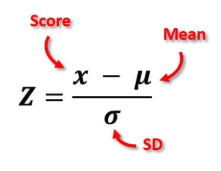

In [9]:
stimulus_mean = baseline_eligible_df['signed_contrast'].mean()
stimulus_std = baseline_eligible_df['signed_contrast'].std(ddof=0)

if not np.isfinite(stimulus_std) or stimulus_std == 0:
    stimulus_std = 1.0

baseline_eligible_df['ashwood_stimulus'] = (
    (baseline_eligible_df['signed_contrast'] - stimulus_mean) / stimulus_std
    if TASK_NORMALIZE_STIMULUS
    else baseline_eligible_df['signed_contrast']
)

#### **2.6 Define GLM-HMM Input Columns**

These are the columns that will be passed into the `Ashwood-style GLM-HMM`.

In [10]:
ashwood_model_input_columns = [
    'ashwood_stimulus',
    'prev_choice_centered',
    'prev_choice_x_reward',
    'bias'
]

ashwood_state_weight_labels = {
    'stimulus': 'ashwood_stimulus_weight',
    'previous_choice': 'prev_choice_centered_weight',
    'wsls': 'prev_choice_x_reward_weight',
    'bias': 'bias_weight'
}

#### **2.7 Summarize Each Mouse**

At this point, we already have clean baseline trials from `good sessions`.

Now we `summarize` the data for each mouse.  

We need this because Ashwood fits **`one model per mouse`**, so each mouse must have enough trials and sessions.

In [11]:
# Create one summary row per mouse.
# This tells us how much clean data each mouse has for the selected analysis mode.

mouse_baseline_check_df = (
    baseline_eligible_df
    .groupby('subject', as_index=False)
    .agg(
        n_sessions=('session', 'nunique'),
        n_trials=('choice_binary', 'size'),
        n_right_stimulus=('signed_contrast', lambda x: (x > 0).sum()),
        n_nonzero_stimulus=('signed_contrast', lambda x: (x != 0).sum()),
        n_unbiased_50_50=('block_type', lambda x: (x == 'unbiased_50_50').sum()),
        n_left_biased_80_20=('block_type', lambda x: (x == 'left_biased_80_20').sum()),
        n_right_biased_20_80=('block_type', lambda x: (x == 'right_biased_20_80').sum()),
    )
)

mouse_baseline_check_df['fraction_right_stimulus'] = (
    mouse_baseline_check_df['n_right_stimulus']
    / mouse_baseline_check_df['n_nonzero_stimulus'].replace(0, np.nan)
)

display(mouse_baseline_check_df.head())


,subject,n_sessions,n_trials,n_right_stimulus,n_nonzero_stimulus,n_unbiased_50_50,n_left_biased_80_20,n_right_biased_20_80,fraction_right_stimulus
0,CSHL045,20,1780,685,1451,1780,0,0,0.472088
1,CSHL046,18,1602,637,1294,1602,0,0,0.492272
2,CSHL047,21,1864,777,1521,1864,0,0,0.510848
3,CSHL049,20,1780,731,1455,1780,0,0,0.502405
4,CSHL051,23,2039,829,1649,2039,0,0,0.502729


#### **2.8 Select Mice For `GLM-HMM` Fitting**

Now we choose which mice have enough data for the `Ashwood-style mouse-level GLM-HMM`.

We first try the strict Ashwood-style rule.  

If no mice pass that rule, we use a relaxed fallback rule so the notebook can still run on the local dataset.

In [12]:
# Check which mice satisfy the strict Ashwood-style rule.
# Strict rule = enough sessions and enough total trials.
mouse_baseline_check_df['strict_ashwood_eligible_mouse'] = (
    (mouse_baseline_check_df['n_sessions'] >= TASK_STRICT_MIN_SESSIONS_PER_MOUSE)
    & (mouse_baseline_check_df['n_trials'] >= TASK_MIN_TRIALS_PER_MOUSE)
)

# Check which mice satisfy the relaxed fallback rule.
# This is useful when the local dataset has fewer sessions than the full Ashwood dataset.
mouse_baseline_check_df['available_data_eligible_mouse'] = (
    (mouse_baseline_check_df['n_sessions'] >= TASK_RELAXED_MIN_SESSIONS_PER_MOUSE)
    & (mouse_baseline_check_df['n_trials'] >= TASK_MIN_TRIALS_PER_MOUSE)
)

# Prefer strict Ashwood-style mice.
# If at least one mouse passes the strict rule, use those mice.
if mouse_baseline_check_df['strict_ashwood_eligible_mouse'].any():
    selected_session_rule = (
        f'strict Ashwood-style >= {TASK_STRICT_MIN_SESSIONS_PER_MOUSE} sessions'
    )
    selected_mouse_mask = mouse_baseline_check_df['strict_ashwood_eligible_mouse']

# If no mouse passes the strict rule, use the relaxed fallback rule.
else:
    selected_session_rule = (
        f'available-data fallback >= {TASK_RELAXED_MIN_SESSIONS_PER_MOUSE} sessions'
    )
    selected_mouse_mask = mouse_baseline_check_df['available_data_eligible_mouse']

# Get the subject IDs of mice selected for model fitting.
eligible_mice = mouse_baseline_check_df.loc[
    selected_mouse_mask,
    'subject'
].tolist()

# Optionally limit the number of mice for a faster run.
if TASK_MAX_MICE is not None:
    eligible_mice = eligible_mice[:TASK_MAX_MICE]


# Store selection information in the mouse summary table.
mouse_baseline_check_df['selected_for_fit'] = (
    mouse_baseline_check_df['subject'].isin(eligible_mice)
)
mouse_baseline_check_df['selection_rule'] = selected_session_rule
mouse_baseline_check_df['stimulus_zscore_mean'] = stimulus_mean
mouse_baseline_check_df['stimulus_zscore_std'] = stimulus_std


# Save the final mouse-level data check table.
taskB_baseline_check_df = mouse_baseline_check_df.copy()

# Print a short summary so we can check the dataset.
print('Trial window:', TASK_TRIAL_WINDOW)
print('Block set:', TASK_BLOCK_SET)
print('Analysis preset:', TASK_ANALYSIS_PRESET)
print('Trial scope:', TASK_TRIAL_SCOPE)
print('Selected blocks:', TASK_SELECTED_BLOCK_TYPES)
print('Analysis source:', baseline_source)
print('Baseline candidate rows:', len(baseline_candidate_df))
print('Eligible baseline sessions:', len(eligible_sessions_df))
print('Selected mice:', len(eligible_mice), '| rule:', selected_session_rule)
print('Model input columns:', ashwood_model_input_columns)

display(taskB_baseline_check_df.head())

Trial window: first90_session
Block set: 50_50
Analysis preset: first90_session__50_50
Trial scope: first_n_session_trials
Selected blocks: ['unbiased_50_50']
Analysis source: preset=first90_session__50_50; trial_scope=first_n_session_trials; first_n_trials=90; blocks=['unbiased_50_50']
Baseline candidate rows: 258936
Eligible baseline sessions: 2867
Selected mice: 31 | rule: strict Ashwood-style >= 30 sessions
Model input columns: ['ashwood_stimulus', 'prev_choice_centered', 'prev_choice_x_reward', 'bias']


,subject,n_sessions,n_trials,n_right_stimulus,n_nonzero_stimulus,n_unbiased_50_50,n_left_biased_80_20,n_right_biased_20_80,fraction_right_stimulus,strict_ashwood_eligible_mouse,available_data_eligible_mouse,selected_for_fit,selection_rule,stimulus_zscore_mean,stimulus_zscore_std
0,CSHL045,20,1780,685,1451,1780,0,0,0.472088,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063
1,CSHL046,18,1602,637,1294,1602,0,0,0.492272,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063
2,CSHL047,21,1864,777,1521,1864,0,0,0.510848,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063
3,CSHL049,20,1780,731,1455,1780,0,0,0.502405,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063
4,CSHL051,23,2039,829,1649,2039,0,0,0.502729,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063


## 3. Load Mouse-Level Helper Functions

The helper functions now live in `ssm_new_full/ashwood_mouse_level.py`.

Here we only import them and pass the notebook settings into one config object.


#### **3.1 Import Helper Module And Create Config**

This keeps the notebook short: Section 4 will call these functions instead of defining them again.


In [13]:
# Import Ashwood mouse-level helper functions from the local ssm_new_full package.
from ssm_new_full.ashwood_mouse_level import (
    AshwoodFitConfig,
    compare_models_for_mouse,
    decode_mouse_trials,
    fit_final_three_state_model,
    prepare_mouse_for_fit,
    summarize_mouse_fit,
)

# Store the notebook settings that the helper functions need.
ashwood_fit_config = AshwoodFitConfig(
    input_columns=ashwood_model_input_columns,
    time_sort_column=model_time_sort_column,
    state_weight_labels=ashwood_state_weight_labels,
    stim_weight_col=ashwood_state_weight_labels['stimulus'],
    bias_weight_col=ashwood_state_weight_labels['bias'],
    num_folds=TASK_NUM_FOLDS,
    model_k_list=TASK_MODEL_K_LIST,
    hmm_max_iter=TASK_HMM_MAX_ITER,
    hmm_n_restarts=TASK_HMM_N_RESTARTS,
    stay_probability=TASK_STAY_PROBABILITY,
    prior_sigma=TASK_PRIOR_SIGMA,
    engaged_contrast_min=TASK_ENGAGED_CONTRAST_MIN,
    bias_sign_min=TASK_BIAS_SIGN_MIN,
)

print('Loaded helper module: ssm_new_full.ashwood_mouse_level')


Loaded helper module: ssm_new_full.ashwood_mouse_level


## 4. Fit and Evaluate Mouse-Level Ashwood GLM-HMM Models

Now we fit the actual models.

The goal is simple:

```text
for each mouse
    use all clean 50/50 baseline sessions
    compare 1-state GLM vs GLM-HMM
    fit final 3-state GLM-HMM
    decode hidden states
    summarize states, accuracy, switching, and dwell time
```


#### **4.1 Prepare Containers For Results**

We create empty lists that will store results for every mouse.

Each list becomes one output table later.


In [14]:
# Store results from each mouse before turning them into final tables.
fit_rows = []
comparison_fold_rows = []
state_rows = []
state_weight_rows = []
accuracy_rows = []
occupancy_rows = []
switch_rows = []
dwell_rows = []
decoded_parts = []
mouse_fit_details = {}


#### **4.2 Run Imported Helper Functions For Each Mouse**

The helper functions were imported from `ssm_new_full/ashwood_mouse_level.py`.

This loop is where the analysis actually runs:

```text
for each selected mouse
    prepare ordered baseline sessions
    compare 1-state GLM vs GLM-HMM
    fit final 3-state GLM-HMM
    decode hidden states
    summarize accuracy, occupancy, switching, and dwell time
```


In [15]:
for mouse_idx, subject in enumerate(eligible_mice):
    mouse_df, sessions, n_sessions, n_trials, fold_lookup = prepare_mouse_for_fit(
        subject,
        mouse_idx,
        baseline_eligible_df,
        ashwood_fit_config,
    )
    fit_status = 'ok'

    try:
        # Compare model performance using held-out sessions.
        comparison_fold_rows.extend(
            compare_models_for_mouse(
                subject,
                mouse_idx,
                mouse_df,
                fold_lookup,
                ashwood_fit_config,
            )
        )

        # Fit the final 3-state model and decode trial-by-trial hidden states.
        final_fit = fit_final_three_state_model(
            mouse_idx,
            mouse_df,
            sessions,
            ashwood_fit_config,
        )
        decoded_mouse_df = decode_mouse_trials(final_fit)
        decoded_parts.append(decoded_mouse_df.assign(subject=subject))

        # Convert decoded states into summary rows and tables.
        state_row, state_weight_df, accuracy_row, occupancy_row, switch_row, dwell_row = summarize_mouse_fit(
            subject,
            final_fit,
            decoded_mouse_df,
            ashwood_fit_config,
        )
        state_rows.append(state_row)
        state_weight_rows.append(state_weight_df)
        accuracy_rows.append(accuracy_row)
        occupancy_rows.append(occupancy_row)
        switch_rows.append(switch_row)
        dwell_rows.append(dwell_row)

        mouse_fit_details[subject] = {
            'model3': final_fit['model3'],
            'state_params_df': final_fit['params3'],
            'transition_matrix': final_fit['transition'],
            'decoded_df': decoded_mouse_df,
            'fold_lookup': fold_lookup,
        }

    except Exception as exc:
        fit_status = f'failed: {exc}'

    # Record whether this mouse fit succeeded or failed.
    fit_rows.append({
        'subject': subject,
        'n_sessions': n_sessions,
        'n_trials': n_trials,
        'fit_status': fit_status,
        'selection_rule': selected_session_rule,
    })


#### **4.3 Build The Final Task Tables**

After all mice are processed, we convert the stored rows into pandas tables.

This section is split by output group so it is easier to read and rerun.


##### **4.3.1 Task A: Mouse Fit Status**

This table shows which mice were fit successfully and how much data each mouse had.


In [16]:
# Build the mouse-level fit status table.
taskA_mouse_fit_df = pd.DataFrame(fit_rows)

display(taskA_mouse_fit_df.head())


,subject,n_sessions,n_trials,fit_status,selection_rule
0,CSHL_003,56,4965,ok,strict Ashwood-style >= 30 sessions
1,CSHL_005,50,4451,ok,strict Ashwood-style >= 30 sessions
2,CSHL_008,56,4984,ok,strict Ashwood-style >= 30 sessions
3,CSHL_014,57,5072,ok,strict Ashwood-style >= 30 sessions
4,CSHL_015,42,3738,ok,strict Ashwood-style >= 30 sessions


##### **4.3.2 Task C: Model Comparison**

This table compares the 1-state GLM with the GLM-HMM models using held-out sessions.


In [17]:
# Build the fold-level and mouse-level model comparison tables.
taskC_model_comparison_by_fold_df = pd.DataFrame(comparison_fold_rows)

if not taskC_model_comparison_by_fold_df.empty:
    taskC_model_comparison_df = (
        taskC_model_comparison_by_fold_df
        .groupby(['subject', 'model', 'n_states'], as_index=False)
        .agg(
            test_log_likelihood_per_trial=('test_log_likelihood_per_trial', 'mean'),
            test_accuracy=('test_accuracy', 'mean'),
            n_folds=('fold', 'nunique'),
        )
    )
else:
    taskC_model_comparison_df = pd.DataFrame()

display(taskC_model_comparison_df.head())


,subject,model,n_states,test_log_likelihood_per_trial,test_accuracy,n_folds
0,CSHL_003,1-state GLM,1,-0.434459,0.820538,2
1,CSHL_003,3-state GLM-HMM,3,-0.382069,0.836027,2
2,CSHL_005,1-state GLM,1,-0.479157,0.777349,2
3,CSHL_005,3-state GLM-HMM,3,-0.355847,0.870588,2
4,CSHL_008,1-state GLM,1,-0.485876,0.761437,2


##### **4.3.3 Tasks D-H: State Summary Tables**

These tables summarize state interpretation, accuracy, occupancy, switching, and dwell time.


In [18]:
# Build the Ashwood state summary tables.
# Keep expected columns even when no mouse fit succeeds, so later merge/display cells do not fail.

taskD_state_columns = [
    'subject',
    'engaged_state',
    'left_biased_state',
    'right_biased_state',
    'engaged_state_found',
    'left_biased_state_found',
    'right_biased_state_found',
    'ashwood_state_order_complete',
    'all_3_state_types_found',
    'max_stimulus_weight',
    'min_bias_weight',
    'max_bias_weight',
    'engaged_bias_weight',
    'left_biased_bias_weight',
    'right_biased_bias_weight',
]

ashwood_state_weight_columns = [
    'subject',
    'state',
    'suggested_label',
    'strongest_weight',
    'strongest_weight_value',
    'signed_contrast_weight',
    'bias_weight',
    'prev_choice_centered_weight',
    'prev_choice_x_reward_weight',
]

taskE_accuracy_columns = [
    'subject',
    'accuracy_engaged',
    'accuracy_left_biased',
    'accuracy_right_biased',
    'overall_accuracy',
]

taskF_occupancy_columns = [
    'subject',
    'engaged_fraction',
    'left_biased_fraction',
    'right_biased_fraction',
]

taskG_switching_columns = [
    'subject',
    'fraction_sessions_with_any_switch',
    'fraction_sessions_with_multiple_switches',
    'median_switches_per_session',
]

taskH_dwell_columns = [
    'subject',
    'mean_self_transition_probability',
    'expected_dwell_time_engaged',
    'expected_dwell_time_left_biased',
    'expected_dwell_time_right_biased',
]

taskD_state_interpretation_df = pd.DataFrame(state_rows, columns=taskD_state_columns)
ashwood_state_weight_table_df = (
    pd.concat(state_weight_rows, ignore_index=True)
    if state_weight_rows
    else pd.DataFrame(columns=ashwood_state_weight_columns)
)
taskE_accuracy_by_state_df = pd.DataFrame(accuracy_rows, columns=taskE_accuracy_columns)
taskF_state_occupancy_df = pd.DataFrame(occupancy_rows, columns=taskF_occupancy_columns)
taskG_state_switching_df = pd.DataFrame(switch_rows, columns=taskG_switching_columns)
taskH_dwell_self_transition_df = pd.DataFrame(dwell_rows, columns=taskH_dwell_columns)
mouse_decoded_baseline_df = (
    pd.concat(decoded_parts, ignore_index=True)
    if decoded_parts
    else pd.DataFrame()
)


## 5. Tasks D-H: Mouse-Level Ashwood Summary Tables

This section displays the main per-mouse Ashwood-style state tables.


#### **5.1 State Weight Table**

This table shows the fitted GLM weights for each hidden state.


In [19]:
# Show the fitted GLM weights for each state and mouse.
display(ashwood_state_weight_table_df.head(10))


,subject,state,suggested_label,strongest_weight,strongest_weight_value,signed_contrast_weight,bias_weight,prev_choice_centered_weight,prev_choice_x_reward_weight
0,CSHL_003,0,stimulus-sensitive / engaged,signed_contrast,10.292381,10.292381,0.196134,0.192708,-0.069912
1,CSHL_003,1,left-biased / disengaged,signed_contrast,1.607342,1.607342,-1.050049,0.267619,0.159708
2,CSHL_003,2,right-biased / disengaged,signed_contrast,1.737964,1.737964,1.234385,0.471912,0.139899
3,CSHL_005,0,stimulus-sensitive / engaged,signed_contrast,6.057185,6.057185,1.079837,0.564700,-0.055149
4,CSHL_005,1,right-biased / disengaged,signed_contrast,5.335919,5.335919,-0.929651,0.240873,0.427761
5,CSHL_005,2,left-biased / disengaged,prev_choice_centered,2.801438,0.753156,-1.056655,2.801438,0.151764
6,CSHL_008,0,stimulus-sensitive / engaged,signed_contrast,6.734029,6.734029,-0.827927,0.093693,0.112696
7,CSHL_008,1,right-biased / disengaged,signed_contrast,5.142562,5.142562,0.979228,-0.156402,0.252040
8,CSHL_008,2,left-biased / disengaged,prev_choice_centered,1.747895,0.913260,-0.109676,1.747895,-0.022064
9,CSHL_014,0,right-biased / disengaged,bias,2.384815,1.054817,2.384815,0.250532,0.435744


#### **5.2 Task D: State Interpretation**

This table checks whether each mouse has engaged, left-biased, and right-biased states.


In [20]:
# Show the Ashwood-style state labels for each mouse.
display(taskD_state_interpretation_df.head())


,subject,engaged_state,left_biased_state,right_biased_state,engaged_state_found,left_biased_state_found,right_biased_state_found,ashwood_state_order_complete,all_3_state_types_found,max_stimulus_weight,min_bias_weight,max_bias_weight,engaged_bias_weight,left_biased_bias_weight,right_biased_bias_weight
0,CSHL_003,0,1,2,True,True,True,True,True,10.292381,-1.050049,1.234385,0.196134,-1.050049,1.234385
1,CSHL_005,0,2,1,True,True,False,True,False,6.057185,-1.056655,1.079837,1.079837,-1.056655,-0.929651
2,CSHL_008,0,2,1,True,True,True,True,True,6.734029,-0.827927,0.979228,-0.827927,-0.109676,0.979228
3,CSHL_014,2,1,0,True,True,True,True,True,6.037808,-0.503665,2.384815,-0.487875,-0.503665,2.384815
4,CSHL_015,0,1,2,True,True,True,True,True,6.575360,-1.668727,1.664974,-0.076605,-1.668727,1.664974


#### **5.3 Task E: Accuracy By State**

This table compares accuracy during engaged and biased states.


In [21]:
# Show stimulus accuracy separately for each decoded state type.
display(taskE_accuracy_by_state_df.head())


,subject,accuracy_engaged,accuracy_left_biased,accuracy_right_biased,overall_accuracy
0,CSHL_003,0.926762,0.694064,0.705426,0.853037
1,CSHL_005,0.831813,0.573003,0.828877,0.736216
2,CSHL_008,0.858019,0.608000,0.839656,0.802368
3,CSHL_014,0.848076,0.594595,0.616230,0.757732
4,CSHL_015,0.868653,0.730290,0.627139,0.770046


#### **5.4 Task F: State Occupancy**

This table shows the fraction of trials spent in each state type.


In [22]:
# Show how often each mouse occupies each state type.
display(taskF_state_occupancy_df.head())


,subject,engaged_fraction,left_biased_fraction,right_biased_fraction
0,CSHL_003,0.663444,0.212286,0.124270
1,CSHL_005,0.443721,0.370928,0.185352
2,CSHL_008,0.482343,0.201445,0.316212
3,CSHL_014,0.623226,0.088131,0.288644
4,CSHL_015,0.483949,0.244248,0.271803


#### **5.5 Task G: State Switching Within Sessions**

This table checks whether states switch within sessions instead of staying fixed for a whole session.


In [23]:
# Show how often decoded states switch within sessions.
display(taskG_state_switching_df.head())


,subject,fraction_sessions_with_any_switch,fraction_sessions_with_multiple_switches,median_switches_per_session
0,CSHL_003,0.482143,0.303571,0.0
1,CSHL_005,0.640000,0.360000,1.0
2,CSHL_008,0.535714,0.250000,1.0
3,CSHL_014,0.736842,0.543860,2.0
4,CSHL_015,0.714286,0.452381,1.0


#### **5.6 Task H: Dwell Time And Self-Transition**

This table measures how persistent the hidden states are across trials.


In [24]:
# Show self-transition probability and expected dwell time for each state type.
display(taskH_dwell_self_transition_df.head())


,subject,mean_self_transition_probability,expected_dwell_time_engaged,expected_dwell_time_left_biased,expected_dwell_time_right_biased
0,CSHL_003,0.960531,78.839434,23.448205,15.853762
1,CSHL_005,0.958497,29.293006,29.811839,17.597542
2,CSHL_008,0.960443,34.932359,20.229475,24.624004
3,CSHL_014,0.946603,30.252464,11.713511,23.943237
4,CSHL_015,0.951792,25.503538,21.157454,17.197308


#### **5.7 Combined Mouse-Level Summary**

This merges the Task A-H outputs into one table for easier interpretation.


In [25]:
# Merge all per-mouse summary tables into one final mouse-level table.
# Use safe merges so the notebook still runs when a selected analysis has no successful fits.

ashwood_mouse_level_summary_df = taskA_mouse_fit_df.copy()

summary_merge_tables = [
    taskB_baseline_check_df[['subject', 'fraction_right_stimulus']]
    if {'subject', 'fraction_right_stimulus'}.issubset(taskB_baseline_check_df.columns)
    else pd.DataFrame(columns=['subject', 'fraction_right_stimulus']),
    taskD_state_interpretation_df,
    taskE_accuracy_by_state_df,
    taskF_state_occupancy_df,
    taskG_state_switching_df,
    taskH_dwell_self_transition_df,
]

for summary_table in summary_merge_tables:
    if 'subject' in summary_table.columns:
        ashwood_mouse_level_summary_df = ashwood_mouse_level_summary_df.merge(
            summary_table,
            on='subject',
            how='left',
        )

display(ashwood_mouse_level_summary_df.head())

if ashwood_mouse_level_summary_df.empty:
    print('No mouse-level summary rows were created. Check taskA_mouse_fit_df for fit_status messages.')
elif 'fit_status' in ashwood_mouse_level_summary_df.columns:
    failed_fits = ashwood_mouse_level_summary_df[ashwood_mouse_level_summary_df['fit_status'] != 'ok']
    if not failed_fits.empty:
        print('Some fits failed. Check fit_status below:')
        display(failed_fits[['subject', 'fit_status']].head(10))


,subject,n_sessions,n_trials,fit_status,selection_rule,fraction_right_stimulus,engaged_state,left_biased_state,right_biased_state,engaged_state_found,...,engaged_fraction,left_biased_fraction,right_biased_fraction,fraction_sessions_with_any_switch,fraction_sessions_with_multiple_switches,median_switches_per_session,mean_self_transition_probability,expected_dwell_time_engaged,expected_dwell_time_left_biased,expected_dwell_time_right_biased
0,CSHL_003,56,4965,ok,strict Ashwood-style >= 30 sessions,0.498841,0,1,2,True,...,0.663444,0.212286,0.124270,0.482143,0.303571,0.0,0.960531,78.839434,23.448205,15.853762
1,CSHL_005,50,4451,ok,strict Ashwood-style >= 30 sessions,0.488619,0,2,1,True,...,0.443721,0.370928,0.185352,0.640000,0.360000,1.0,0.958497,29.293006,29.811839,17.597542
2,CSHL_008,56,4984,ok,strict Ashwood-style >= 30 sessions,0.498179,0,2,1,True,...,0.482343,0.201445,0.316212,0.535714,0.250000,1.0,0.960443,34.932359,20.229475,24.624004
3,CSHL_014,57,5072,ok,strict Ashwood-style >= 30 sessions,0.499018,2,1,0,True,...,0.623226,0.088131,0.288644,0.736842,0.543860,2.0,0.946603,30.252464,11.713511,23.943237
4,CSHL_015,42,3738,ok,strict Ashwood-style >= 30 sessions,0.496024,0,1,2,True,...,0.483949,0.244248,0.271803,0.714286,0.452381,1.0,0.951792,25.503538,21.157454,17.197308


#### **5.8 Task 2-3: Engagement Across Block Types**

This table compares decoded state occupancy across 50/50, 80/20, and 20/80 blocks.


In [26]:
# Compare state occupancy across block types for the selected extension analysis.
# If no mouse fit succeeded, return empty tables instead of raising a KeyError.

block_engagement_columns = [
    'subject',
    'block_type',
    'n_trials',
    'engaged_fraction',
    'left_biased_fraction',
    'right_biased_fraction',
    'accuracy',
]
block_engagement_summary_columns = [
    'block_type',
    'n_mice',
    'mean_engaged_fraction',
    'median_engaged_fraction',
    'mean_left_biased_fraction',
    'mean_right_biased_fraction',
    'mean_accuracy',
]

required_decoded_columns = {
    'subject',
    'block_type',
    'most_likely_state',
    'engaged_state',
    'left_biased_state',
    'right_biased_state',
    'signed_contrast',
    'choice_binary',
}

if not mouse_decoded_baseline_df.empty and required_decoded_columns.issubset(mouse_decoded_baseline_df.columns):
    block_decoded_df = mouse_decoded_baseline_df[
        mouse_decoded_baseline_df['block_type'].isin(TASK_SELECTED_BLOCK_TYPES)
    ].copy()
else:
    block_decoded_df = pd.DataFrame()

if not block_decoded_df.empty:
    block_decoded_df['is_engaged'] = (
        block_decoded_df['most_likely_state'] == block_decoded_df['engaged_state']
    )
    block_decoded_df['is_left_biased'] = (
        block_decoded_df['most_likely_state'] == block_decoded_df['left_biased_state']
    )
    block_decoded_df['is_right_biased'] = (
        block_decoded_df['most_likely_state'] == block_decoded_df['right_biased_state']
    )
    block_decoded_df['stimulus_correct'] = np.where(
        block_decoded_df['signed_contrast'] != 0,
        (
            ((block_decoded_df['signed_contrast'] > 0) & (block_decoded_df['choice_binary'] == 1))
            | ((block_decoded_df['signed_contrast'] < 0) & (block_decoded_df['choice_binary'] == 0))
        ),
        np.nan,
    )

    task23_block_engagement_df = (
        block_decoded_df
        .groupby(['subject', 'block_type'], as_index=False)
        .agg(
            n_trials=('choice_binary', 'size'),
            engaged_fraction=('is_engaged', 'mean'),
            left_biased_fraction=('is_left_biased', 'mean'),
            right_biased_fraction=('is_right_biased', 'mean'),
            accuracy=('stimulus_correct', 'mean'),
        )
    )

    task23_block_engagement_summary_df = (
        task23_block_engagement_df
        .groupby('block_type', as_index=False)
        .agg(
            n_mice=('subject', 'nunique'),
            mean_engaged_fraction=('engaged_fraction', 'mean'),
            median_engaged_fraction=('engaged_fraction', 'median'),
            mean_left_biased_fraction=('left_biased_fraction', 'mean'),
            mean_right_biased_fraction=('right_biased_fraction', 'mean'),
            mean_accuracy=('accuracy', 'mean'),
        )
    )
else:
    task23_block_engagement_df = pd.DataFrame(columns=block_engagement_columns)
    task23_block_engagement_summary_df = pd.DataFrame(columns=block_engagement_summary_columns)

if not task23_block_engagement_df.empty:
    task23_block_engagement_df['block_type'] = pd.Categorical(
        task23_block_engagement_df['block_type'],
        categories=TASK_SELECTED_BLOCK_TYPES,
        ordered=True,
    )
    task23_block_engagement_df = task23_block_engagement_df.sort_values(['subject', 'block_type'])

if not task23_block_engagement_summary_df.empty:
    task23_block_engagement_summary_df['block_type'] = pd.Categorical(
        task23_block_engagement_summary_df['block_type'],
        categories=TASK_SELECTED_BLOCK_TYPES,
        ordered=True,
    )
    task23_block_engagement_summary_df = task23_block_engagement_summary_df.sort_values('block_type')

display(task23_block_engagement_df.head())
display(task23_block_engagement_summary_df)

if task23_block_engagement_df.empty:
    print('No decoded block engagement rows. Check whether mouse fits succeeded for this selected dataset.')


,subject,block_type,n_trials,engaged_fraction,left_biased_fraction,right_biased_fraction,accuracy
0,CSHL_003,unbiased_50_50,4965,0.663444,0.212286,0.124270,0.853037
1,CSHL_005,unbiased_50_50,4451,0.443721,0.370928,0.185352,0.736216
2,CSHL_008,unbiased_50_50,4984,0.482343,0.201445,0.316212,0.802368
3,CSHL_014,unbiased_50_50,5072,0.623226,0.088131,0.288644,0.757732
4,CSHL_015,unbiased_50_50,3738,0.483949,0.244248,0.271803,0.770046


,block_type,n_mice,mean_engaged_fraction,median_engaged_fraction,mean_left_biased_fraction,mean_right_biased_fraction,mean_accuracy
0,unbiased_50_50,31,0.53808,0.505533,0.213317,0.248603,0.806624


#### **5.9 Around Block Switches**

Question: do decoded states change when the task switches into a new block?

We compare trials just before a block switch, the switch trial, early trials after the switch, later trials after the switch, and the stable part of the block. This is the table to use for adaptation / exploration around block changes.


In [27]:
# Build an around-switch table to test whether states change before and after block transitions.
# The key columns to inspect are engaged_fraction, biased-state fractions, and accuracy by switch_epoch.

switch_epoch_columns = [
    'subject',
    'switch_epoch',
    'n_trials',
    'engaged_fraction',
    'left_biased_fraction',
    'right_biased_fraction',
    'accuracy',
]

switch_epoch_summary_columns = [
    'switch_epoch',
    'n_mice',
    'mean_engaged_fraction',
    'mean_left_biased_fraction',
    'mean_right_biased_fraction',
    'mean_accuracy',
]

required_switch_columns = {
    'subject',
    'session',
    'most_likely_state',
    'engaged_state',
    'left_biased_state',
    'right_biased_state',
    'signed_contrast',
    'choice_binary',
    'block_switch_trial',
    'trials_after_block_switch',
}

switch_epoch_order = [
    'before_switch_30_to_1',
    'switch_trial',
    'after_switch_1_to_10',
    'after_switch_11_to_30',
    'after_switch_31_plus',
    'other',
]

if not mouse_decoded_baseline_df.empty and required_switch_columns.issubset(mouse_decoded_baseline_df.columns):
    switch_decoded_df = mouse_decoded_baseline_df.copy()

    sort_columns = ['subject', 'session']
    if 'intervals_0' in switch_decoded_df.columns:
        sort_columns.append('intervals_0')
    elif 'ashwood_trial_number' in switch_decoded_df.columns:
        sort_columns.append('ashwood_trial_number')

    switch_decoded_df = switch_decoded_df.sort_values(sort_columns).copy()
    switch_decoded_df['block_switch_trial'] = switch_decoded_df['block_switch_trial'].fillna(False).astype(bool)
    switch_decoded_df['trials_after_block_switch'] = pd.to_numeric(
        switch_decoded_df['trials_after_block_switch'],
        errors='coerce',
    )

    def add_trials_until_next_switch(session_df):
        session_df = session_df.copy()
        switch_positions = np.flatnonzero(session_df['block_switch_trial'].to_numpy())
        trials_until_next_switch = np.full(len(session_df), np.nan)

        for switch_position in switch_positions:
            start_position = max(0, switch_position - 30)
            before_positions = np.arange(start_position, switch_position)
            trials_until_next_switch[before_positions] = switch_position - before_positions

        session_df['trials_until_next_block_switch'] = trials_until_next_switch
        return session_df

    switch_decoded_df = (
        switch_decoded_df
        .groupby(['subject', 'session'], group_keys=False)
        .apply(add_trials_until_next_switch)
        .reset_index(drop=True)
    )

    switch_decoded_df['is_engaged'] = (
        switch_decoded_df['most_likely_state'] == switch_decoded_df['engaged_state']
    )
    switch_decoded_df['is_left_biased'] = (
        switch_decoded_df['most_likely_state'] == switch_decoded_df['left_biased_state']
    )
    switch_decoded_df['is_right_biased'] = (
        switch_decoded_df['most_likely_state'] == switch_decoded_df['right_biased_state']
    )
    switch_decoded_df['stimulus_correct'] = np.where(
        switch_decoded_df['signed_contrast'] != 0,
        (
            ((switch_decoded_df['signed_contrast'] > 0) & (switch_decoded_df['choice_binary'] == 1))
            | ((switch_decoded_df['signed_contrast'] < 0) & (switch_decoded_df['choice_binary'] == 0))
        ),
        np.nan,
    )

    switch_decoded_df['switch_epoch'] = np.select(
        [
            switch_decoded_df['trials_until_next_block_switch'].between(1, 30, inclusive='both'),
            switch_decoded_df['block_switch_trial'],
            switch_decoded_df['trials_after_block_switch'].between(1, 10, inclusive='both'),
            switch_decoded_df['trials_after_block_switch'].between(11, 30, inclusive='both'),
            switch_decoded_df['trials_after_block_switch'] > 30,
        ],
        [
            'before_switch_30_to_1',
            'switch_trial',
            'after_switch_1_to_10',
            'after_switch_11_to_30',
            'after_switch_31_plus',
        ],
        default='other',
    )

    task24_switch_epoch_df = (
        switch_decoded_df
        .groupby(['subject', 'switch_epoch'], as_index=False)
        .agg(
            n_trials=('choice_binary', 'size'),
            engaged_fraction=('is_engaged', 'mean'),
            left_biased_fraction=('is_left_biased', 'mean'),
            right_biased_fraction=('is_right_biased', 'mean'),
            accuracy=('stimulus_correct', 'mean'),
        )
    )

    task24_switch_epoch_summary_df = (
        task24_switch_epoch_df
        .groupby('switch_epoch', as_index=False)
        .agg(
            n_mice=('subject', 'nunique'),
            mean_engaged_fraction=('engaged_fraction', 'mean'),
            mean_left_biased_fraction=('left_biased_fraction', 'mean'),
            mean_right_biased_fraction=('right_biased_fraction', 'mean'),
            mean_accuracy=('accuracy', 'mean'),
        )
    )
else:
    task24_switch_epoch_df = pd.DataFrame(columns=switch_epoch_columns)
    task24_switch_epoch_summary_df = pd.DataFrame(columns=switch_epoch_summary_columns)

for switch_table in [task24_switch_epoch_df, task24_switch_epoch_summary_df]:
    if not switch_table.empty and 'switch_epoch' in switch_table.columns:
        switch_table['switch_epoch'] = pd.Categorical(
            switch_table['switch_epoch'],
            categories=switch_epoch_order,
            ordered=True,
        )
        switch_table.sort_values('switch_epoch', inplace=True)

if not task24_switch_epoch_df.empty:
    task24_switch_epoch_df = task24_switch_epoch_df.sort_values(['subject', 'switch_epoch'])

print('Per-mouse around-switch table')
display(task24_switch_epoch_df.head(20))
print('Population around-switch summary')
display(task24_switch_epoch_summary_df)

if task24_switch_epoch_df.empty:
    print('No around-switch rows. Use full_session or first90_block if you want switch-related trials.')


Per-mouse around-switch table


/var/folders/cm/nwhknbzj75ncc8pffcxj8sbm0000gn/T/ipykernel_87372/1778951034.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_trials_until_next_switch)


,subject,switch_epoch,n_trials,engaged_fraction,left_biased_fraction,right_biased_fraction,accuracy
3,CSHL_003,before_switch_30_to_1,270,0.196296,0.455556,0.348148,0.782609
5,CSHL_003,switch_trial,4,0.250000,0.500000,0.250000,0.750000
1,CSHL_003,after_switch_1_to_10,559,0.618962,0.264758,0.116279,0.849794
0,CSHL_003,after_switch_11_to_30,1066,0.647280,0.193246,0.159475,0.844639
2,CSHL_003,after_switch_31_plus,3013,0.720212,0.186193,0.093594,0.864037
4,CSHL_003,other,53,0.641509,0.264151,0.094340,0.826087
7,CSHL_005,after_switch_1_to_10,500,0.316000,0.524000,0.160000,0.695652
6,CSHL_005,after_switch_11_to_30,1000,0.413000,0.397000,0.190000,0.723476
8,CSHL_005,after_switch_31_plus,2901,0.479145,0.332299,0.188556,0.747193
9,CSHL_005,other,50,0.280000,0.560000,0.160000,0.750000


Population around-switch summary


,switch_epoch,n_mice,mean_engaged_fraction,mean_left_biased_fraction,mean_right_biased_fraction,mean_accuracy
3,before_switch_30_to_1,12,0.327648,0.341229,0.331123,0.766194
5,switch_trial,12,0.409130,0.299598,0.291272,0.933664
1,after_switch_1_to_10,31,0.520306,0.230468,0.249225,0.794994
0,after_switch_11_to_30,31,0.543779,0.208408,0.247814,0.806985
2,after_switch_31_plus,31,0.551143,0.203613,0.245245,0.811708
4,other,31,0.514776,0.235527,0.249697,0.818309


#### **5.10 Lapses / Errors By State**

Question: are errors concentrated in engaged state or in biased / disengaged states?

Here `error_rate` uses non-zero stimulus trials. `high_contrast_lapse_rate` is stricter: it asks whether the mouse makes errors even when the stimulus should be easier. If this rate is higher in biased states, lapses are more consistent with biased/disengaged behavior than pure random mistakes.


In [28]:
# Build an error/lapse table by decoded state type.
# This helps test whether lapses are mostly happening in biased states or also inside engaged state.

lapse_columns = [
    'subject',
    'state_label',
    'n_trials',
    'n_nonzero_trials',
    'n_high_contrast_trials',
    'error_rate',
    'high_contrast_lapse_rate',
    'zero_contrast_fraction',
]

lapse_summary_columns = [
    'state_label',
    'n_mice',
    'mean_error_rate',
    'mean_high_contrast_lapse_rate',
    'mean_zero_contrast_fraction',
]

required_lapse_columns = {
    'subject',
    'most_likely_state',
    'engaged_state',
    'left_biased_state',
    'right_biased_state',
    'signed_contrast',
    'choice_binary',
}

state_label_order = ['engaged', 'left_biased', 'right_biased', 'other']

if not mouse_decoded_baseline_df.empty and required_lapse_columns.issubset(mouse_decoded_baseline_df.columns):
    lapse_decoded_df = mouse_decoded_baseline_df.copy()
    lapse_decoded_df['abs_contrast'] = lapse_decoded_df['signed_contrast'].abs()
    nonzero_abs_contrast = lapse_decoded_df.loc[lapse_decoded_df['abs_contrast'] > 0, 'abs_contrast']
    high_contrast_threshold = nonzero_abs_contrast.quantile(0.75) if not nonzero_abs_contrast.empty else np.nan

    lapse_decoded_df['state_label'] = np.select(
        [
            lapse_decoded_df['most_likely_state'] == lapse_decoded_df['engaged_state'],
            lapse_decoded_df['most_likely_state'] == lapse_decoded_df['left_biased_state'],
            lapse_decoded_df['most_likely_state'] == lapse_decoded_df['right_biased_state'],
        ],
        ['engaged', 'left_biased', 'right_biased'],
        default='other',
    )

    lapse_decoded_df['is_nonzero_stimulus'] = lapse_decoded_df['abs_contrast'] > 0
    lapse_decoded_df['is_zero_contrast'] = lapse_decoded_df['abs_contrast'] == 0
    lapse_decoded_df['is_high_contrast'] = (
        lapse_decoded_df['abs_contrast'] >= high_contrast_threshold
        if np.isfinite(high_contrast_threshold)
        else False
    )
    lapse_decoded_df['stimulus_correct'] = np.where(
        lapse_decoded_df['is_nonzero_stimulus'],
        (
            ((lapse_decoded_df['signed_contrast'] > 0) & (lapse_decoded_df['choice_binary'] == 1))
            | ((lapse_decoded_df['signed_contrast'] < 0) & (lapse_decoded_df['choice_binary'] == 0))
        ),
        np.nan,
    )
    lapse_decoded_df['stimulus_error'] = np.where(
        lapse_decoded_df['is_nonzero_stimulus'],
        ~lapse_decoded_df['stimulus_correct'].astype(bool),
        np.nan,
    )
    lapse_decoded_df['high_contrast_error'] = np.where(
        lapse_decoded_df['is_high_contrast'],
        lapse_decoded_df['stimulus_error'],
        np.nan,
    )

    task25_lapse_by_state_df = (
        lapse_decoded_df
        .groupby(['subject', 'state_label'], as_index=False)
        .agg(
            n_trials=('choice_binary', 'size'),
            n_nonzero_trials=('is_nonzero_stimulus', 'sum'),
            n_high_contrast_trials=('is_high_contrast', 'sum'),
            error_rate=('stimulus_error', 'mean'),
            high_contrast_lapse_rate=('high_contrast_error', 'mean'),
            zero_contrast_fraction=('is_zero_contrast', 'mean'),
        )
    )

    task25_lapse_by_state_summary_df = (
        task25_lapse_by_state_df
        .groupby('state_label', as_index=False)
        .agg(
            n_mice=('subject', 'nunique'),
            mean_error_rate=('error_rate', 'mean'),
            mean_high_contrast_lapse_rate=('high_contrast_lapse_rate', 'mean'),
            mean_zero_contrast_fraction=('zero_contrast_fraction', 'mean'),
        )
    )
else:
    high_contrast_threshold = np.nan
    task25_lapse_by_state_df = pd.DataFrame(columns=lapse_columns)
    task25_lapse_by_state_summary_df = pd.DataFrame(columns=lapse_summary_columns)

for lapse_table in [task25_lapse_by_state_df, task25_lapse_by_state_summary_df]:
    if not lapse_table.empty and 'state_label' in lapse_table.columns:
        lapse_table['state_label'] = pd.Categorical(
            lapse_table['state_label'],
            categories=state_label_order,
            ordered=True,
        )
        lapse_table.sort_values('state_label', inplace=True)

if not task25_lapse_by_state_df.empty:
    task25_lapse_by_state_df = task25_lapse_by_state_df.sort_values(['subject', 'state_label'])

print('High contrast threshold used for lapse check:', high_contrast_threshold)
print('Per-mouse lapse/error table')
display(task25_lapse_by_state_df.head(20))
print('Population lapse/error summary')
display(task25_lapse_by_state_summary_df)

if task25_lapse_by_state_df.empty:
    print('No lapse rows. Check whether decoded trials exist for this selected dataset.')


High contrast threshold used for lapse check: 1.0
Per-mouse lapse/error table


,subject,state_label,n_trials,n_nonzero_trials,n_high_contrast_trials,error_rate,high_contrast_lapse_rate,zero_contrast_fraction
0,CSHL_003,engaged,3294,2922,731,0.073238,0.000000,0.112933
1,CSHL_003,left_biased,1054,876,198,0.305936,0.085859,0.168880
2,CSHL_003,right_biased,617,516,125,0.294574,0.096000,0.163695
3,CSHL_005,engaged,1975,1754,425,0.168187,0.000000,0.111899
4,CSHL_005,left_biased,1651,1452,373,0.426997,0.402145,0.120533
5,CSHL_005,right_biased,825,748,173,0.171123,0.000000,0.093333
6,CSHL_008,engaged,2404,2120,524,0.141981,0.000000,0.118136
7,CSHL_008,left_biased,1004,875,224,0.392000,0.276786,0.128486
8,CSHL_008,right_biased,1576,1397,354,0.160344,0.005650,0.113579
9,CSHL_014,engaged,3161,2521,621,0.151924,0.000000,0.202468


Population lapse/error summary


,state_label,n_mice,mean_error_rate,mean_high_contrast_lapse_rate,mean_zero_contrast_fraction
0,engaged,31,0.133408,0.000043,0.171364
1,left_biased,31,0.328562,0.197345,0.178775
2,right_biased,31,0.270503,0.120163,0.168538


#### **5.11 Low And Zero Contrast Trials**

Question: do engagement and biased states change when sensory evidence is weak?

Zero contrast means the stimulus has no left/right evidence. Low contrast means weak evidence. If biased states increase at zero or low contrast, then uncertainty may push choices toward bias/history instead of stimulus-driven engagement.


In [29]:
# Compare decoded state occupancy across zero, low, and high contrast trials.
# This directly tests whether uncertainty changes engagement and biased-state occupancy.

contrast_columns = [
    'subject',
    'contrast_bin',
    'n_trials',
    'engaged_fraction',
    'left_biased_fraction',
    'right_biased_fraction',
    'accuracy',
]

contrast_summary_columns = [
    'contrast_bin',
    'n_mice',
    'mean_engaged_fraction',
    'mean_left_biased_fraction',
    'mean_right_biased_fraction',
    'mean_accuracy',
]

required_contrast_columns = {
    'subject',
    'most_likely_state',
    'engaged_state',
    'left_biased_state',
    'right_biased_state',
    'signed_contrast',
    'choice_binary',
}

contrast_bin_order = ['zero_contrast', 'low_contrast', 'high_contrast']

if not mouse_decoded_baseline_df.empty and required_contrast_columns.issubset(mouse_decoded_baseline_df.columns):
    contrast_decoded_df = mouse_decoded_baseline_df.copy()
    contrast_decoded_df['abs_contrast'] = contrast_decoded_df['signed_contrast'].abs()
    nonzero_abs_contrast = contrast_decoded_df.loc[contrast_decoded_df['abs_contrast'] > 0, 'abs_contrast']
    low_contrast_threshold = nonzero_abs_contrast.quantile(0.50) if not nonzero_abs_contrast.empty else np.nan

    contrast_decoded_df['contrast_bin'] = np.select(
        [
            contrast_decoded_df['abs_contrast'] == 0,
            contrast_decoded_df['abs_contrast'].between(0, low_contrast_threshold, inclusive='right'),
            contrast_decoded_df['abs_contrast'] > low_contrast_threshold,
        ],
        ['zero_contrast', 'low_contrast', 'high_contrast'],
        default='unknown_contrast',
    )

    contrast_decoded_df['is_engaged'] = (
        contrast_decoded_df['most_likely_state'] == contrast_decoded_df['engaged_state']
    )
    contrast_decoded_df['is_left_biased'] = (
        contrast_decoded_df['most_likely_state'] == contrast_decoded_df['left_biased_state']
    )
    contrast_decoded_df['is_right_biased'] = (
        contrast_decoded_df['most_likely_state'] == contrast_decoded_df['right_biased_state']
    )
    contrast_decoded_df['stimulus_correct'] = np.where(
        contrast_decoded_df['signed_contrast'] != 0,
        (
            ((contrast_decoded_df['signed_contrast'] > 0) & (contrast_decoded_df['choice_binary'] == 1))
            | ((contrast_decoded_df['signed_contrast'] < 0) & (contrast_decoded_df['choice_binary'] == 0))
        ),
        np.nan,
    )

    task26_contrast_state_df = (
        contrast_decoded_df[contrast_decoded_df['contrast_bin'].isin(contrast_bin_order)]
        .groupby(['subject', 'contrast_bin'], as_index=False)
        .agg(
            n_trials=('choice_binary', 'size'),
            engaged_fraction=('is_engaged', 'mean'),
            left_biased_fraction=('is_left_biased', 'mean'),
            right_biased_fraction=('is_right_biased', 'mean'),
            accuracy=('stimulus_correct', 'mean'),
        )
    )

    task26_contrast_state_summary_df = (
        task26_contrast_state_df
        .groupby('contrast_bin', as_index=False)
        .agg(
            n_mice=('subject', 'nunique'),
            mean_engaged_fraction=('engaged_fraction', 'mean'),
            mean_left_biased_fraction=('left_biased_fraction', 'mean'),
            mean_right_biased_fraction=('right_biased_fraction', 'mean'),
            mean_accuracy=('accuracy', 'mean'),
        )
    )
else:
    low_contrast_threshold = np.nan
    task26_contrast_state_df = pd.DataFrame(columns=contrast_columns)
    task26_contrast_state_summary_df = pd.DataFrame(columns=contrast_summary_columns)

for contrast_table in [task26_contrast_state_df, task26_contrast_state_summary_df]:
    if not contrast_table.empty and 'contrast_bin' in contrast_table.columns:
        contrast_table['contrast_bin'] = pd.Categorical(
            contrast_table['contrast_bin'],
            categories=contrast_bin_order,
            ordered=True,
        )
        contrast_table.sort_values('contrast_bin', inplace=True)

if not task26_contrast_state_df.empty:
    task26_contrast_state_df = task26_contrast_state_df.sort_values(['subject', 'contrast_bin'])

print('Low contrast threshold used:', low_contrast_threshold)
print('Per-mouse contrast table')
display(task26_contrast_state_df.head(20))
print('Population contrast summary')
display(task26_contrast_state_summary_df)

if task26_contrast_state_df.empty:
    print('No contrast rows. Check whether decoded trials exist for this selected dataset.')


Low contrast threshold used: 0.25
Per-mouse contrast table


,subject,contrast_bin,n_trials,engaged_fraction,left_biased_fraction,right_biased_fraction,accuracy
2,CSHL_003,zero_contrast,651,0.571429,0.273425,0.155146,NaN
1,CSHL_003,low_contrast,3241,0.674792,0.209195,0.116014,0.813638
0,CSHL_003,high_contrast,1073,0.684995,0.184529,0.130475,0.972041
5,CSHL_005,zero_contrast,497,0.444668,0.400402,0.154930,NaN
4,CSHL_005,low_contrast,2983,0.445525,0.361716,0.192759,0.700637
3,CSHL_005,high_contrast,971,0.437693,0.384140,0.178167,0.845520
8,CSHL_008,zero_contrast,592,0.479730,0.217905,0.302365,NaN
7,CSHL_008,low_contrast,3290,0.485106,0.197872,0.317021,0.755623
6,CSHL_008,high_contrast,1102,0.475499,0.203267,0.321234,0.941924
11,CSHL_014,zero_contrast,998,0.641283,0.077154,0.281563,NaN


Population contrast summary


,contrast_bin,n_mice,mean_engaged_fraction,mean_left_biased_fraction,mean_right_biased_fraction,mean_accuracy
2,zero_contrast,31,0.537747,0.222744,0.239509,NaN
1,low_contrast,31,0.539631,0.210536,0.249833,0.762967
0,high_contrast,31,0.532795,0.215001,0.252204,0.937335


## 6. Task I: Population Summary Across Mice


In [30]:
# Summarize the results across mice and check whether engaged-state accuracy is higher than biased-state accuracy.

if 'fit_status' in ashwood_mouse_level_summary_df.columns:
    valid_summary = ashwood_mouse_level_summary_df[
        ashwood_mouse_level_summary_df['fit_status'] == 'ok'
    ].copy()
else:
    valid_summary = pd.DataFrame()

def safe_mean(column_name):
    return valid_summary[column_name].mean() if column_name in valid_summary.columns and not valid_summary.empty else np.nan

def safe_median(column_name):
    return valid_summary[column_name].median() if column_name in valid_summary.columns and not valid_summary.empty else np.nan

def safe_bool_sum(column_name):
    return int(valid_summary[column_name].fillna(False).sum()) if column_name in valid_summary.columns and not valid_summary.empty else 0

population_summary = {
    'number_of_mice': len(valid_summary),
    'mice_with_complete_ashwood_state_order': safe_bool_sum('ashwood_state_order_complete'),
    'mice_showing_all_3_state_types': safe_bool_sum('all_3_state_types_found'),
    'mean_engaged_fraction': safe_mean('engaged_fraction'),
    'median_engaged_fraction': safe_median('engaged_fraction'),
    'mean_accuracy_engaged': safe_mean('accuracy_engaged'),
    'median_accuracy_engaged': safe_median('accuracy_engaged'),
    'mean_accuracy_left_biased': safe_mean('accuracy_left_biased'),
    'median_accuracy_left_biased': safe_median('accuracy_left_biased'),
    'mean_accuracy_right_biased': safe_mean('accuracy_right_biased'),
    'median_accuracy_right_biased': safe_median('accuracy_right_biased'),
    'mean_median_switches_per_session': safe_mean('median_switches_per_session'),
    'median_median_switches_per_session': safe_median('median_switches_per_session'),
    'mean_self_transition_probability': safe_mean('mean_self_transition_probability'),
}

taskI_population_summary_df = pd.DataFrame([population_summary])
display(taskI_population_summary_df)

required_accuracy_columns = {'accuracy_engaged', 'accuracy_left_biased', 'accuracy_right_biased'}
if not valid_summary.empty and required_accuracy_columns.issubset(valid_summary.columns):
    engaged_better_than_biased = (
        valid_summary['accuracy_engaged']
        > valid_summary[['accuracy_left_biased', 'accuracy_right_biased']].mean(axis=1)
    )
    print('Mice where engaged accuracy > mean biased-state accuracy:', int(engaged_better_than_biased.sum()), '/', len(valid_summary))
else:
    print('No successful mouse fits available for engaged-vs-biased accuracy comparison.')


,number_of_mice,mice_with_complete_ashwood_state_order,mice_showing_all_3_state_types,mean_engaged_fraction,median_engaged_fraction,mean_accuracy_engaged,median_accuracy_engaged,mean_accuracy_left_biased,median_accuracy_left_biased,mean_accuracy_right_biased,median_accuracy_right_biased,mean_median_switches_per_session,median_median_switches_per_session,mean_self_transition_probability
0,31,31,25,0.53808,0.505533,0.866592,0.868653,0.671438,0.64359,0.729497,0.699507,0.83871,1.0,0.951889


Mice where engaged accuracy > mean biased-state accuracy: 31 / 31


### How to choose an analysis

Change only these two lines in Settings:

```python
TASK_TRIAL_WINDOW = 'full_session'
TASK_BLOCK_SET = 'all_blocks'
```

Common choices:

```python
# Ashwood baseline
TASK_TRIAL_WINDOW = 'first90_session'
TASK_BLOCK_SET = '50_50'
```

```python
# First 90 trials after 80/20 block starts
TASK_TRIAL_WINDOW = 'first90_block'
TASK_BLOCK_SET = '80_20'
```

```python
# Full 20/80 blocks only
TASK_TRIAL_WINDOW = 'full_session'
TASK_BLOCK_SET = '20_80'
```

```python
# Full sessions, compare all block types together
TASK_TRIAL_WINDOW = 'full_session'
TASK_BLOCK_SET = 'all_blocks'
```

Use `task23_block_engagement_summary_df` to compare engagement across the selected block types.


### Note

This notebook is an extension, not the original Ashwood baseline replication.

The baseline notebook tests whether we can reproduce the Ashwood first-90 50/50 result.

This extension asks what happens when we include full sessions with 50/50, 80/20, and 20/80 blocks.


## Export Results For Sex Analysis

Run this cell after the extension analysis finishes.

It saves the main result tables needed by the separate sex-analysis notebook, without rerunning the GLM-HMM.


In [31]:
# Save the main extension result tables for the separate sex-analysis notebook.
# The sex-analysis notebook reads this file and compares male/female results without refitting the GLM-HMM.
# Sex labels are exported from all_trials if all_trials already has sex and sex_raw columns.

import pickle

sex_export_names = [
    'ashwood_mouse_level_summary_df',
    'task23_block_engagement_df',
    'task24_switch_epoch_df',
    'task25_lapse_by_state_df',
    'task26_contrast_state_df',
    'taskI_population_summary_df',
]

sex_export_payload = {}
for table_name in sex_export_names:
    if table_name in globals():
        sex_export_payload[table_name] = globals()[table_name]
    else:
        print('Missing table, not exported:', table_name)

# Build subject-level sex labels from all_trials already loaded in this notebook.
subject_sex_df = pd.DataFrame(columns=['subject', 'sex', 'sex_raw'])
sex_balance_df = pd.DataFrame(columns=['sex', 'n_mice', 'n_sessions', 'n_trials'])
sex_source = 'not found'

if 'all_trials' in globals() and {'subject', 'sex'}.issubset(all_trials.columns):
    sex_columns = ['subject', 'sex']
    if 'sex_raw' in all_trials.columns:
        sex_columns.append('sex_raw')

    all_trials_sex_source_df = all_trials[sex_columns].copy()
    all_trials_sex_source_df['subject'] = all_trials_sex_source_df['subject'].astype(str)
    all_trials_sex_source_df['sex'] = all_trials_sex_source_df['sex'].astype(str).str.strip().str.lower()
    all_trials_sex_source_df['sex'] = all_trials_sex_source_df['sex'].map({
        'm': 'male',
        'male': 'male',
        'f': 'female',
        'female': 'female',
    }).fillna(all_trials_sex_source_df['sex'])

    if 'sex_raw' not in all_trials_sex_source_df.columns:
        all_trials_sex_source_df['sex_raw'] = all_trials_sex_source_df['sex']

    subject_sex_df = (
        all_trials_sex_source_df[['subject', 'sex', 'sex_raw']]
        .drop_duplicates('subject')
        .reset_index(drop=True)
    )

    if 'session' in all_trials.columns:
        sex_balance_df = (
            all_trials
            .merge(subject_sex_df[['subject', 'sex']], on='subject', how='left', suffixes=('', '_subject'))
            .assign(sex=lambda df: df['sex_subject'].fillna(df['sex']) if 'sex_subject' in df.columns else df['sex'])
            .groupby('sex', dropna=False)
            .agg(
                n_mice=('subject', 'nunique'),
                n_sessions=('session', 'nunique'),
                n_trials=('subject', 'size'),
            )
            .reset_index()
        )
    else:
        sex_balance_df = (
            subject_sex_df
            .groupby('sex', dropna=False)
            .agg(n_mice=('subject', 'nunique'))
            .reset_index()
        )
        sex_balance_df['n_sessions'] = np.nan
        sex_balance_df['n_trials'] = np.nan

    sex_source = 'all_trials.sex / all_trials.sex_raw'

elif 'baseline_eligible_df' in globals() and {'subject', 'sex'}.issubset(baseline_eligible_df.columns):
    subject_sex_df = (
        baseline_eligible_df[['subject', 'sex']]
        .drop_duplicates('subject')
        .reset_index(drop=True)
    )
    subject_sex_df['sex_raw'] = subject_sex_df['sex']
    sex_balance_df = (
        baseline_eligible_df
        .groupby('sex', dropna=False)
        .agg(
            n_mice=('subject', 'nunique'),
            n_sessions=('session', 'nunique'),
            n_trials=('subject', 'size'),
        )
        .reset_index()
    )
    sex_source = 'baseline_eligible_df.sex'

sex_export_payload['subject_sex_df'] = subject_sex_df
sex_export_payload['sex_balance_df'] = sex_balance_df
sex_export_payload['sex_source'] = sex_source

sex_export_payload['analysis_settings'] = {
    'TASK_TRIAL_WINDOW': TASK_TRIAL_WINDOW,
    'TASK_BLOCK_SET': TASK_BLOCK_SET,
    'TASK_ANALYSIS_PRESET': TASK_ANALYSIS_PRESET,
    'TASK_TRIAL_SCOPE': TASK_TRIAL_SCOPE,
    'TASK_FIRST_N_TRIALS': TASK_FIRST_N_TRIALS,
    'TASK_SELECTED_BLOCK_TYPES': TASK_SELECTED_BLOCK_TYPES,
    'TASK_SELECTED_PROBABILITY_LEFT_VALUES': TASK_SELECTED_PROBABILITY_LEFT_VALUES,
}

def safe_filename_part(value):
    text = str(value)
    text = text.replace(' ', '_').replace('/', '-').replace('\\', '-')
    safe_text = ''.join(
        character if character.isalnum() or character in {'_', '-', '.'} else '_'
        for character in text
    )
    while '__' in safe_text:
        safe_text = safe_text.replace('__', '_')
    return safe_text.strip('_') or 'none'

extension_export_filename = (
    f'ashwood_extension_results_{safe_filename_part(TASK_TRIAL_WINDOW)}_{safe_filename_part(TASK_BLOCK_SET)}.pkl'
)
extension_export_path = OUTPUT_DIR / extension_export_filename

sex_export_payload['export_filename'] = extension_export_filename
sex_export_payload['export_path'] = str(extension_export_path)

with open(extension_export_path, 'wb') as f:
    pickle.dump(sex_export_payload, f)

print('Saved extension export:', extension_export_path)
print('Sex source:', sex_source)
display(subject_sex_df.head())
display(sex_balance_df)
print('Exported tables:', sorted(sex_export_payload.keys()))


Saved extension export: notebook_outputs/ashwood_extension_results_first90_session_50_50.pkl
Sex source: all_trials.sex / all_trials.sex_raw


,subject,sex,sex_raw
0,CSHL045,male,M
1,CSHL046,male,M
2,CSHL047,male,M
3,CSHL049,male,M
4,CSHL051,female,F


,sex,n_mice,n_sessions,n_trials
0,female,60,3865,2525576
1,male,80,4270,3007030


Exported tables: ['analysis_settings', 'ashwood_mouse_level_summary_df', 'export_filename', 'export_path', 'sex_balance_df', 'sex_source', 'subject_sex_df', 'task23_block_engagement_df', 'task24_switch_epoch_df', 'task25_lapse_by_state_df', 'task26_contrast_state_df', 'taskI_population_summary_df']


In [32]:
display(taskI_population_summary_df)

,number_of_mice,mice_with_complete_ashwood_state_order,mice_showing_all_3_state_types,mean_engaged_fraction,median_engaged_fraction,mean_accuracy_engaged,median_accuracy_engaged,mean_accuracy_left_biased,median_accuracy_left_biased,mean_accuracy_right_biased,median_accuracy_right_biased,mean_median_switches_per_session,median_median_switches_per_session,mean_self_transition_probability
0,31,31,25,0.53808,0.505533,0.866592,0.868653,0.671438,0.64359,0.729497,0.699507,0.83871,1.0,0.951889
